# Tarea Unidad 4: Sistemas de Recomendación.

**Integrantes:**
- Abril Minerva Estrada Montaño
- Erick José Fabián Sandoval

**Intruccciones:**
Toma el dataset de Netflix y crea un sistema de recomendación: https://www.kaggle.com/datasets/netflix-inc/netflix-prize-data?select=movie_titles.csv 

---



In [3]:
import numpy as np
import pandas as pd

### Introducción

En este notebook se desarrolla un sistema de recomendación utilizando datos de Netflix.  
El objetivo principal es aplicar tecnicas de mineria de elementos frecuentes para encontrar patrones de los usuarios y los contenidos que ven para construir modelos que permitan predecir qué títulos podrían interesarle a cada usuario.  

A lo largo del proceso se:

- Carga y limpia el conjunto de datos.
- Genera reglas de asociación entre usuarios y/o entre ítems.
- Implementa modelos de recomendación (basados en elementos frecuentes).


In [7]:
from tqdm import tqdm

path = "C:\\Users\\GoodM\\OneDrive\\Escritorio\\ErickPython\\combined_data_4.txt"

# Sólo se uso el primer millon de registros por disponibilidad de recursos
N = 1_000_000
data = []
current_movie = None

with open(path, 'r') as f:
    for i, line in enumerate(f):
        if i > N: break
        line = line.strip()
        if line.endswith(':'):
            current_movie = line.replace(':', '')
        else:
            try:
                user, rating, date = line.split(',')
                data.append([int(user), int(current_movie), int(rating)])
            except:
                continue

df = pd.DataFrame(data, columns=['user_id', 'movie_id', 'rating'])
print(df.head(), "\nTotal records:", len(df))


   user_id  movie_id  rating
0  2385003     13368       4
1   659432     13368       3
2   751812     13368       2
3  2625420     13368       2
4  1650301     13368       1 
Total records: 999856


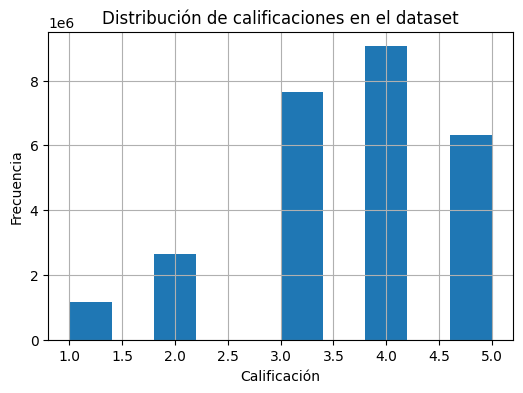

In [31]:
from matplotlib import pyplot as plt

plt.figure(figsize=(6,4))
df['rating'].hist()
plt.title("Distribución de calificaciones en el dataset")
plt.xlabel("Calificación")
plt.ylabel("Frecuencia")
plt.show()

In [8]:
df = df[df['rating'] >= 3]

# Agrupar peliculas por usuario
transactions = df.groupby('user_id')['movie_id'].apply(list).reset_index()

print("Sample transaction:")
print(transactions.head())

# Guardar
transactions.to_csv("transactions.csv", index=False)


Sample transaction:
   user_id                                           movie_id
0        6  [13378, 13391, 13402, 13458, 13462, 13471, 13488]
1        7  [13383, 13384, 13388, 13392, 13402, 13433, 134...
2       10                                     [13391, 13462]
3       42                                     [13466, 13488]
4       59                                            [13383]


In [9]:
import warnings
warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    module="jupyter_client.session"
)

In [12]:
from mlxtend.frequent_patterns import apriori, association_rules

In [13]:
# Por eficiencia se usaron las top 5000 peliculas
top_movies = df['movie_id'].value_counts().head(5000).index
df = df[df['movie_id'].isin(top_movies)]

# Se crea el modelo mercado canasta
basket = (df.groupby(['user_id', 'movie_id'])['rating']
           .count().unstack().fillna(0))
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

basket.head()


C:\Users\GoodM\AppData\Local\Temp\ipykernel_11960\139590605.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x > 0 else 0)


movie_id,13368,13369,13370,13371,13372,13373,13374,13375,13376,13377,...,13503,13504,13505,13506,13507,13508,13509,13510,13511,13512
user_id,,,,,,,,,,,,,,,,,,,,,
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
42,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
frequent_itemsets = apriori(basket, min_support=0.01, use_colnames=True)
frequent_itemsets.sort_values('support', ascending=False).head()


c:\Users\GoodM\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
24,0.350393,(13462)
9,0.280087,(13402)
6,0.258982,(13391)
7,0.167723,(13392)
27,0.159115,(13471)


In [15]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(13384),(13378),0.126192,0.055847,0.019363,0.153442,2.747534,1.0,0.012316,1.115284,0.727892,0.119029,0.103368,0.250080
1,(13378),(13384),0.055847,0.126192,0.019363,0.346718,2.747534,1.0,0.012316,1.337565,0.673659,0.119029,0.252373,0.250080
2,(13378),(13389),0.055847,0.052989,0.010542,0.188765,3.562349,1.0,0.007583,1.167370,0.761833,0.107249,0.143373,0.193856
3,(13389),(13378),0.052989,0.055847,0.010542,0.198947,3.562349,1.0,0.007583,1.178640,0.759533,0.107249,0.151564,0.193856
4,(13378),(13391),0.055847,0.258982,0.022500,0.402893,1.555683,1.0,0.008037,1.241015,0.378324,0.076970,0.194208,0.244887


### Baseline Apriori 

En esta sección aplicamos reglas de asociación para identificar patrones frecuentes en los contenidos vistos por los usuarios.  El objetivo es encontrar combinaciones de títulos que suelen consumirse juntos, lo cual sirve como base para recomendaciones basadas en afinidad.

### Pasos realizados:

1. **Construcción del conjunto de transacciones**  
   - Se agrupan los títulos consumidos por cada usuario para crear una lista de transacciones.
   - Cada transacción representa los títulos o categorías que un usuario ha visto.

2. **Aplicación de Apriori**  
   - Se generan ítems frecuentes utilizando un `min_support` definido.
   - Se identifican las combinaciones de títulos que aparecen juntas de manera recurrente.

3. **Generación de reglas de asociación**  
   - Usamos métricas como:
     - **Support:** frecuencia del patrón.
     - **Confidence:** probabilidad de que ocurra el consecuente dado el antecedente.
     - **Lift:** ganancia real de la regla (valores > 1 indican relación positiva).

4. **Interpretación de resultados**  
   - Las reglas permiten identificar qué contenido tiende a consumirse junto con otro.
   - Estas relaciones se utilizan más adelante como insumo para enriquecer las recomendaciones.

In [16]:
file_path = "C:\\Users\\GoodM\\OneDrive\\Escritorio\\ErickPython\\combined_data_4.txt"

movie_id = None
rows = []

# Leer linea por linea
with open(file_path, 'r') as file:
    for line in file:
        line = line.strip()
        if line.endswith(':'):
            # Line is a movie ID
            movie_id = line.replace(':', '')
        else:
            # Line is user data: user_id, rating, date
            parts = line.split(',')
            if len(parts) == 3:
                user_id, rating, date = parts
                rows.append((user_id, movie_id, float(rating)))

# Create DataFrame
df = pd.DataFrame(rows, columns=['user_id', 'movie_id', 'rating'])
df.head()


,user_id,movie_id,rating
0,2385003,13368,4.0
1,659432,13368,3.0
2,751812,13368,2.0
3,2625420,13368,2.0
4,1650301,13368,1.0


In [17]:
# Muestra aleatoria de 5000 usuarios por eficiencia
sample_users = df['user_id'].drop_duplicates().sample(n=5000, random_state=42)

df_sample = df[df['user_id'].isin(sample_users)]

df_sample['watched'] = 1

# pivote
basket = df_sample.pivot_table(index='user_id',
                               columns='movie_id',
                               values='watched',
                               fill_value=0)

basket.head()


C:\Users\GoodM\AppData\Local\Temp\ipykernel_11960\792151828.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sample['watched'] = 1


movie_id,13368,13369,13370,13371,13372,13373,13374,13375,13377,13378,...,17760,17761,17762,17763,17764,17765,17766,17768,17769,17770
user_id,,,,,,,,,,,,,,,,,,,,,
1001413,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1001990,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1002515,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1002780,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1002924,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
basket = df_sample.pivot_table(index='user_id',
                               columns='movie_id',
                               values='watched',
                               fill_value=0)

print("Basket shape:", basket.shape)

Basket shape: (5000, 3932)


In [19]:
basket = basket.loc[:, basket.sum() > 50]

In [20]:
basket = basket.astype(bool)


In [21]:
# Filtrar con frecuencia de 1-itemsets
freq1 = basket.sum().reset_index()
freq1.columns = ['movie_id', 'count']
freq1 = freq1[freq1['count'] >= 100]  # min frequency threshold

# Guardar solo las peliculas frecuentes
basket_filtered = basket[freq1['movie_id'].values]
print("After hash-tree inspired filtering:", basket_filtered.shape)


After hash-tree inspired filtering: (5000, 534)


In [22]:
import time

start = time.time()

# Ejecutar apriori
frequent_itemsets = apriori(
        basket_filtered,
        min_support=0.05,
        use_colnames=True,
        max_len=2,
        low_memory=True
    )

# Reglas generales
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules.sort_values(by="lift", ascending=False)

end = time.time()

print(f"Apriori completed in {end - start:.2f} seconds")
print(f"Frequent itemsets found: {len(frequent_itemsets)}")
print(f"Rules generated: {len(rules)}")

rules.head()

Apriori completed in 0.25 seconds
Frequent itemsets found: 9656
Rules generated: 18706


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
6008,(14302),(16147),0.0828,0.0946,0.0636,0.768116,8.119619,1.0,0.055767,3.904538,0.955998,0.558875,0.743888,0.720210
6009,(16147),(14302),0.0946,0.0828,0.0636,0.672304,8.119619,1.0,0.055767,2.798939,0.968458,0.558875,0.642722,0.720210
17541,(17621),(16552),0.0904,0.0922,0.0550,0.608407,6.598775,1.0,0.046665,2.318224,0.932780,0.431034,0.568635,0.602468
17540,(16552),(17621),0.0922,0.0904,0.0550,0.596529,6.598775,1.0,0.046665,2.254439,0.934630,0.431034,0.556431,0.602468
15628,(15818),(16825),0.1058,0.0850,0.0508,0.480151,5.648838,1.0,0.041807,1.760127,0.920345,0.362857,0.431859,0.538899


### Generación de Recomendaciones de Películas

En esta sección construimos el modelo final de recomendación:  

In [23]:
# Extraer 5 recomendaciones por cada pelicula antecedente
top_recommendations = (
    rules.sort_values(by="lift", ascending=False)
         .groupby("antecedents")
         .head(5)
         .reset_index(drop=True)
)

top_recommendations.head(10)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(14302),(16147),0.0828,0.0946,0.0636,0.768116,8.119619,1.0,0.055767,3.904538,0.955998,0.558875,0.743888,0.720210
1,(16147),(14302),0.0946,0.0828,0.0636,0.672304,8.119619,1.0,0.055767,2.798939,0.968458,0.558875,0.642722,0.720210
2,(17621),(16552),0.0904,0.0922,0.0550,0.608407,6.598775,1.0,0.046665,2.318224,0.932780,0.431034,0.568635,0.602468
3,(16552),(17621),0.0922,0.0904,0.0550,0.596529,6.598775,1.0,0.046665,2.254439,0.934630,0.431034,0.556431,0.602468
4,(15818),(16825),0.1058,0.0850,0.0508,0.480151,5.648838,1.0,0.041807,1.760127,0.920345,0.362857,0.431859,0.538899
5,(16825),(15818),0.0850,0.1058,0.0508,0.597647,5.648838,1.0,0.041807,2.222427,0.899423,0.362857,0.550041,0.538899
6,(13534),(14667),0.0826,0.1400,0.0604,0.731235,5.223106,1.0,0.048836,3.199820,0.881342,0.372380,0.687482,0.581332
7,(14667),(13534),0.1400,0.0826,0.0604,0.431429,5.223106,1.0,0.048836,1.613518,0.940166,0.372380,0.380236,0.581332
8,(14780),(15953),0.1496,0.0684,0.0506,0.338235,4.944960,1.0,0.040367,1.407751,0.938116,0.302270,0.289647,0.539001
9,(15953),(14780),0.0684,0.1496,0.0506,0.739766,4.944960,1.0,0.040367,3.267829,0.856348,0.302270,0.693986,0.539001


In [24]:
# Cargar titulos
titles = pd.read_csv(
    "C:\\Users\\GoodM\\OneDrive\\Escritorio\\ErickPython\\movie_titles.csv",
    header=None,
    names=["movie_id", "year", "title"],
    encoding="ISO-8859-1",
    engine="python",
    on_bad_lines="skip"
)

# Convertir a diccionario
id_to_title = dict(zip(titles["movie_id"], titles["title"]))

# Agregar nombres
def convert_movies(movie_set):
    return [id_to_title.get(int(x), str(x)) for x in list(movie_set)]

top_recommendations["antecedents"] = top_recommendations["antecedents"].apply(convert_movies)
top_recommendations["consequents"] = top_recommendations["consequents"].apply(convert_movies)

top_recommendations.head(10)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,[The Sopranos: Season 2],[The Sopranos: Season 1],0.0828,0.0946,0.0636,0.768116,8.119619,1.0,0.055767,3.904538,0.955998,0.558875,0.743888,0.720210
1,[The Sopranos: Season 1],[The Sopranos: Season 2],0.0946,0.0828,0.0636,0.672304,8.119619,1.0,0.055767,2.798939,0.968458,0.558875,0.642722,0.720210
2,[Tomorrow Never Dies],[GoldenEye],0.0904,0.0922,0.0550,0.608407,6.598775,1.0,0.046665,2.318224,0.932780,0.431034,0.568635,0.602468
3,[GoldenEye],[Tomorrow Never Dies],0.0922,0.0904,0.0550,0.596529,6.598775,1.0,0.046665,2.254439,0.934630,0.431034,0.556431,0.602468
4,[The Mask of Zorro],[Maverick],0.1058,0.0850,0.0508,0.480151,5.648838,1.0,0.041807,1.760127,0.920345,0.362857,0.431859,0.538899
5,[Maverick],[The Mask of Zorro],0.0850,0.1058,0.0508,0.597647,5.648838,1.0,0.041807,2.222427,0.899423,0.362857,0.550041,0.538899
6,[Bull Durham],[Field of Dreams],0.0826,0.1400,0.0604,0.731235,5.223106,1.0,0.048836,3.199820,0.881342,0.372380,0.687482,0.581332
7,[Field of Dreams],[Bull Durham],0.1400,0.0826,0.0604,0.431429,5.223106,1.0,0.048836,1.613518,0.940166,0.372380,0.380236,0.581332
8,[Beetlejuice],[Bill & Ted's Excellent Adventure],0.1496,0.0684,0.0506,0.338235,4.944960,1.0,0.040367,1.407751,0.938116,0.302270,0.289647,0.539001
9,[Bill & Ted's Excellent Adventure],[Beetlejuice],0.0684,0.1496,0.0506,0.739766,4.944960,1.0,0.040367,3.267829,0.856348,0.302270,0.693986,0.539001


In [25]:
def recommend_movies(movie_name, rules_df, top_n=5):
    recs = rules_df[rules_df['antecedents'].apply(lambda x: movie_name in str(x))]
    recs = recs.sort_values(by='lift', ascending=False).head(top_n)
    return recs[['antecedents', 'consequents', 'confidence', 'lift']]



### Ejemplos:

In [27]:
recommend_movies("Beetlejuice", top_recommendations, top_n=5)

,antecedents,consequents,confidence,lift
8,[Beetlejuice],[Bill & Ted's Excellent Adventure],0.338235,4.944960
17,[Beetlejuice],[Three Amigos],0.421123,4.796389
22,[Beetlejuice],[The Naked Gun],0.435829,4.686332
40,[Beetlejuice],[The Crow],0.355615,4.412096
55,[Beetlejuice],[Bull Durham],0.355615,4.305266


In [28]:
recommend_movies("The Mask of Zorro", top_recommendations, top_n=5)

,antecedents,consequents,confidence,lift
4,[The Mask of Zorro],[Maverick],0.480151,5.648838
123,[The Mask of Zorro],[True Lies],0.667297,4.019860
174,[The Mask of Zorro],[Batman],0.655955,3.872223
177,[The Mask of Zorro],[Tombstone],0.472590,3.867347
199,[The Mask of Zorro],[The Devil's Advocate],0.546314,3.809720
